# End-to-End Business Analytics Project

## 1 Problem Description

You are supposed to build a model that can predict the median housing price in some district in California.<br>
This information can be used to determine whether it is worth investing in a given property in some given area or not.



## 2 Getting Data

For this project we will use the California housing prices data set from the StatLib repository. The dataset contains metrics like population, number of rooms, ocean proximity, median income, median housing prices, etc. for block groups in California. Block groups are the smallest geographical units for which the US Census Bureau publishes sample data.
The dataset is already downloaded as “housing.csv”. In a first step we will import this dataset as a Pandas dataframe.

In [1]:
import pandas as pd

In [2]:
dfHousing = pd.read_csv('housing.csv')

Let us have a closer look at the dataset by using the `df.head()` and the `df.tail()` methods.

In [3]:
dfHousing.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [4]:
dfHousing.tail()


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND
20639,-121.24,39.37,16.0,2785.0,616.0,1387.0,530.0,2.3886,89400.0,INLAND


The `info()` method is useful to get a quick description of the data in particularly the total number of rows each attributes type and the number of non null values. You may also want to try the `len()` and `df.shape`

In [5]:
dfHousing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


We notice that the variable "total_bedrooms" has some missing values. We will later delete the corresponding rows or columns.

In [6]:
len(dfHousing)

20640

In [7]:
dfHousing.shape

(20640, 10)

In [8]:
# Type of the categorical variable:
type(dfHousing.ocean_proximity[30])

str

Find out how many categories exist and how many districts belong to each of these categories by applying the `value_counts()` method.

In [9]:
dfHousing.ocean_proximity.value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

## 3 Visualize the data to gain insights

### Histogram

Let us draw a histogramm for each of the variables.

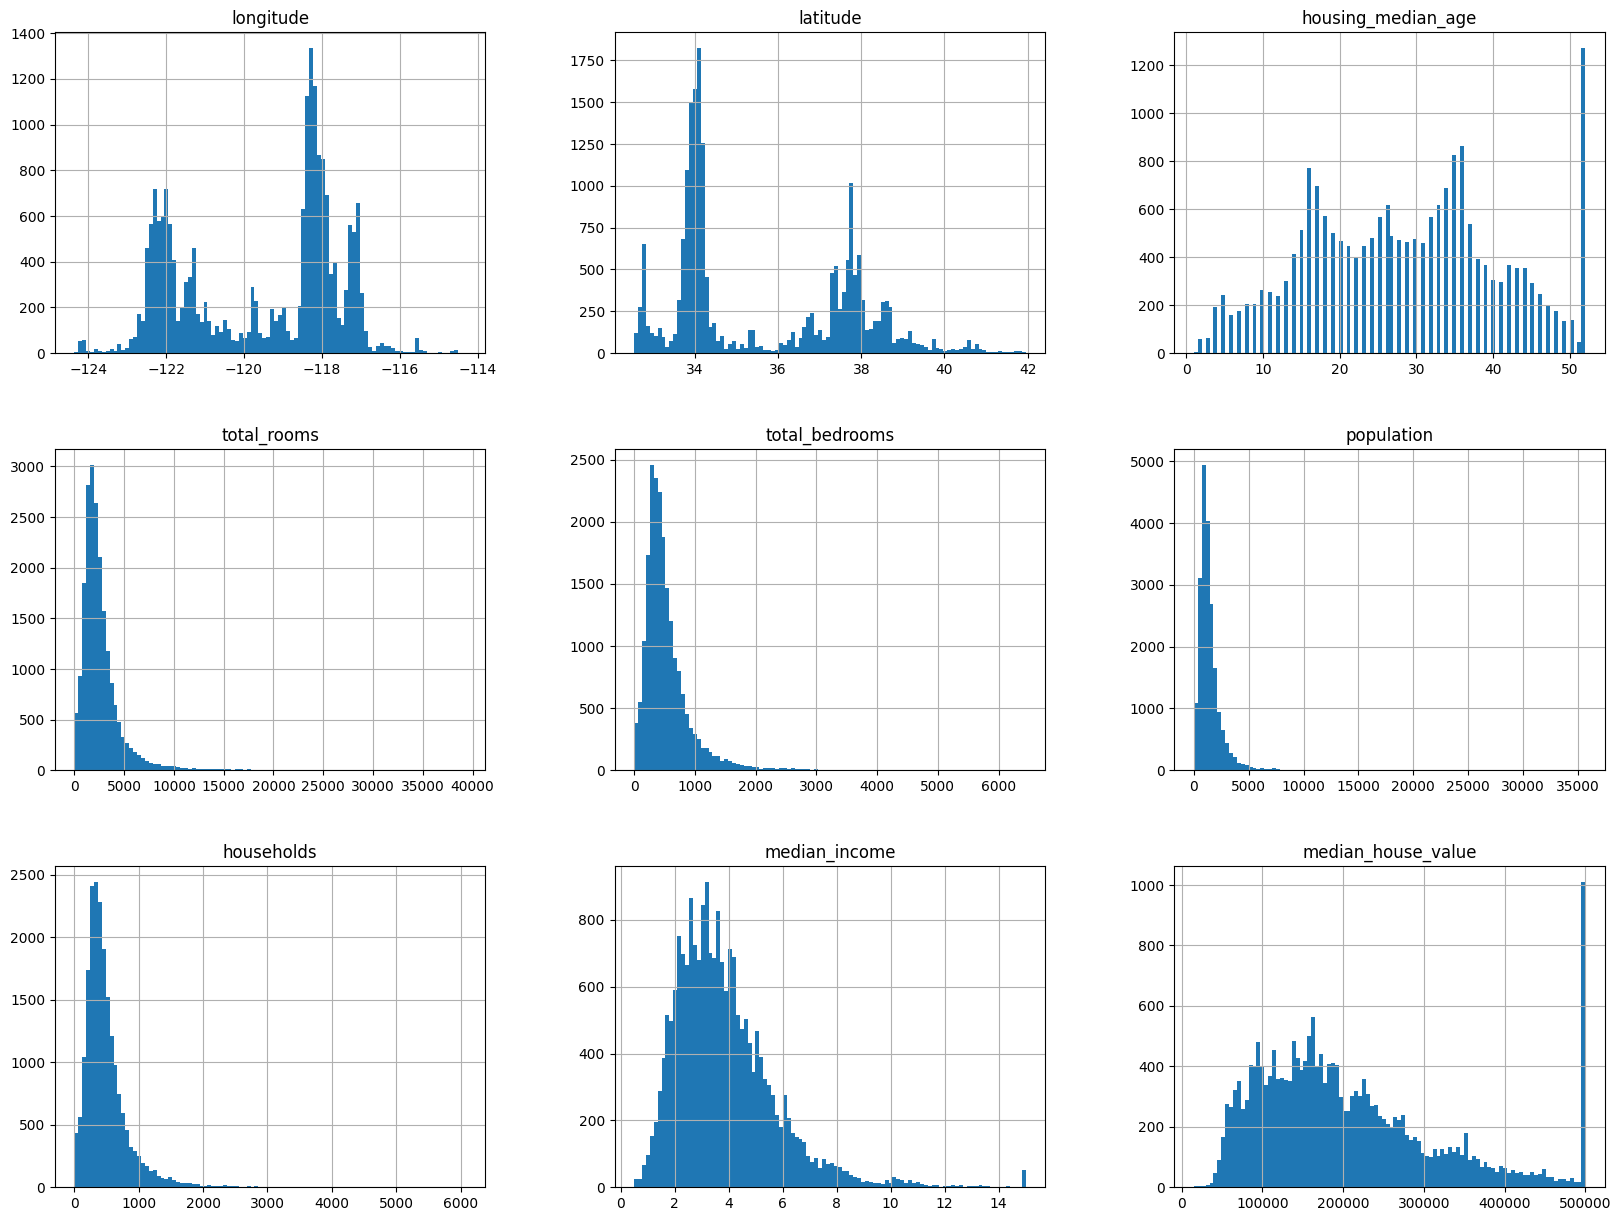

In [10]:
import matplotlib.pyplot as plt

dfHousing.hist(bins = 100, figsize = (20, 15))
plt.show()


# Note that calling show() is optional in Jupiter notebook as
# Jupiter will automatically display plots when a cell is executed

We observe that all the distributions are rather non-symmetrics. The median house value seems to be cut of at 500,000
Also the median housing age seems to have a upper bound in the set.

In [11]:
print('The max house value is:', max(dfHousing.median_house_value))
print('The max house age is:', max(dfHousing.housing_median_age))

The max house value is: 500001.0
The max house age is: 52.0


In [12]:
dfHousing.median_house_value[dfHousing.median_house_value == max(dfHousing.median_house_value)].count()

965

### Geographical plot

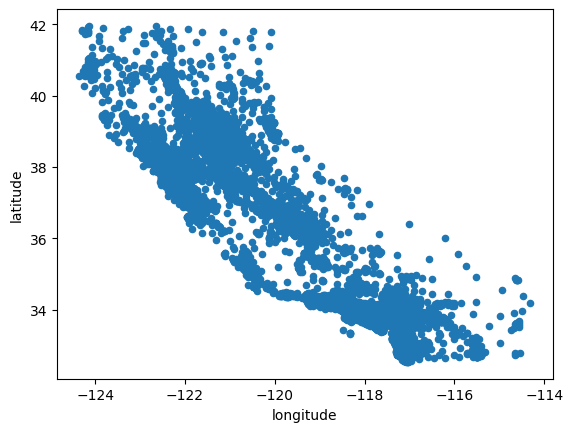

In [13]:
dfHousing.plot(kind = 'scatter', x = 'longitude', y = 'latitude')
plt.show()

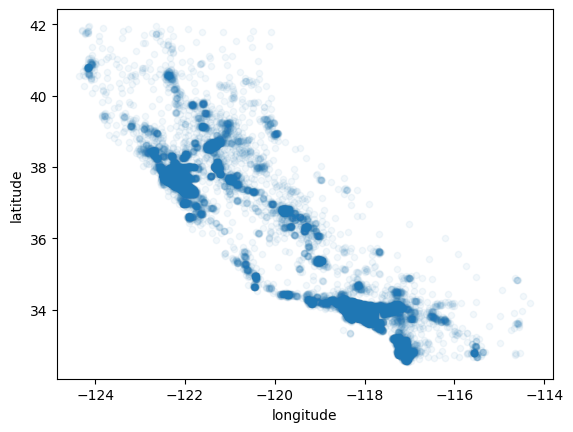

In [14]:
dfHousing.plot(kind = 'scatter', x = 'longitude', y = 'latitude', alpha = 0.05)
plt.show()

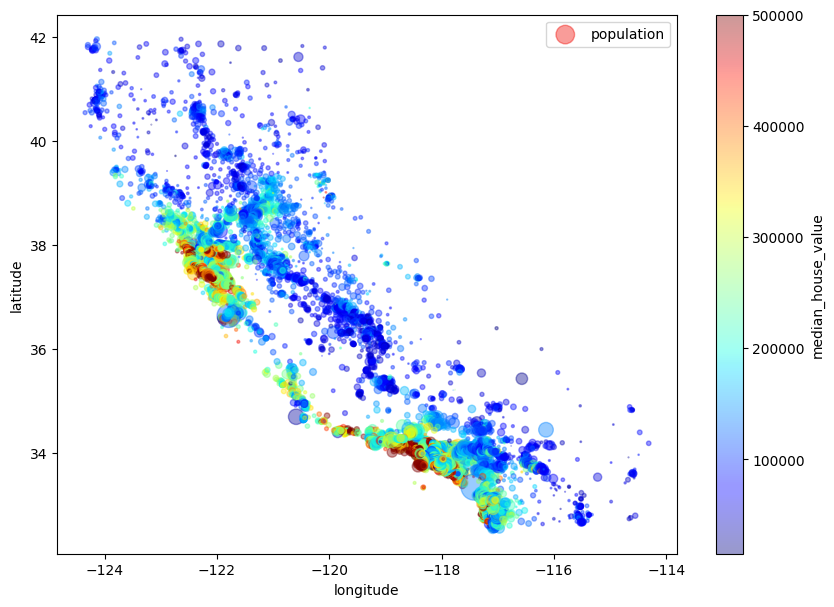

In [15]:
dfHousing.plot(kind="scatter", x="longitude", y="latitude", alpha=0.4,
             s=dfHousing["population"]/100, label="population", figsize=(10,7),
             c="median_house_value", cmap=plt.get_cmap("jet"), colorbar=True,
             sharex=False)
plt.legend()

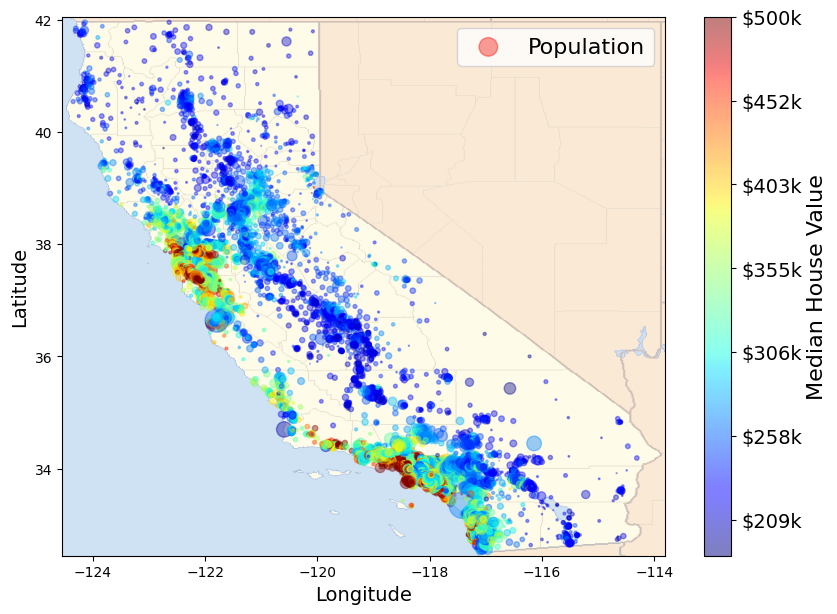

In [16]:
import matplotlib.image as mpimg
import numpy as np

california_img=mpimg.imread('california.png')

ax = dfHousing.plot(kind="scatter", x="longitude", y="latitude", figsize=(10,7),
                  s=dfHousing['population']/100, label="Population",
                  c="median_house_value", cmap=plt.get_cmap("jet"),
                  colorbar=False, alpha=0.4)

plt.imshow(california_img, extent=[-124.55, -113.80, 32.45, 42.05], alpha=0.5,
           cmap=plt.get_cmap("jet"))
plt.ylabel("Latitude", fontsize=14)
plt.xlabel("Longitude", fontsize=14)

prices = dfHousing["median_house_value"]
tick_values = np.linspace(prices.min(), prices.max(), 11)
cbar = plt.colorbar(ticks=tick_values/prices.max())
cbar.ax.set_yticklabels(["$%dk"%(round(v/1000)) for v in tick_values], fontsize=14)
cbar.set_label('Median House Value', fontsize=16)

plt.legend(fontsize=16)

plt.show()

### Looking at Correlations

In [17]:
attributes = ['housing_median_age', 
              'total_rooms', 
              'total_bedrooms', 
              'population', 
              'households', 
              'median_income', 
              'median_house_value']

corrMatrix = dfHousing[attributes].corr()

In [18]:
import seaborn as sb

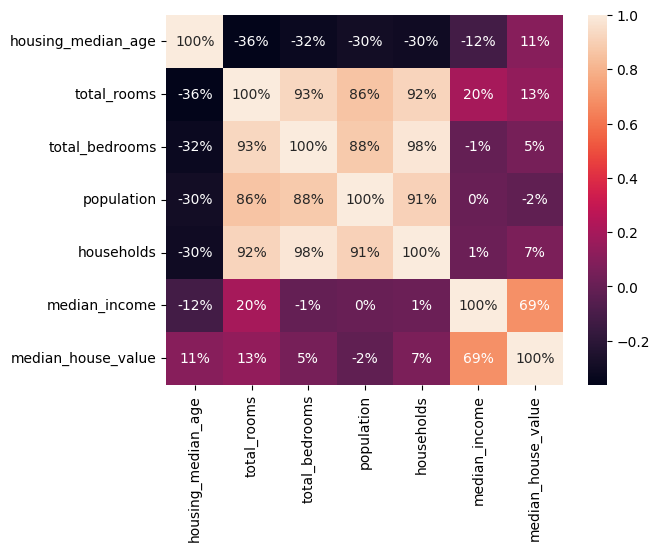

In [19]:
sb.heatmap(corrMatrix, annot = True, fmt = '0.0%')
plt.show()

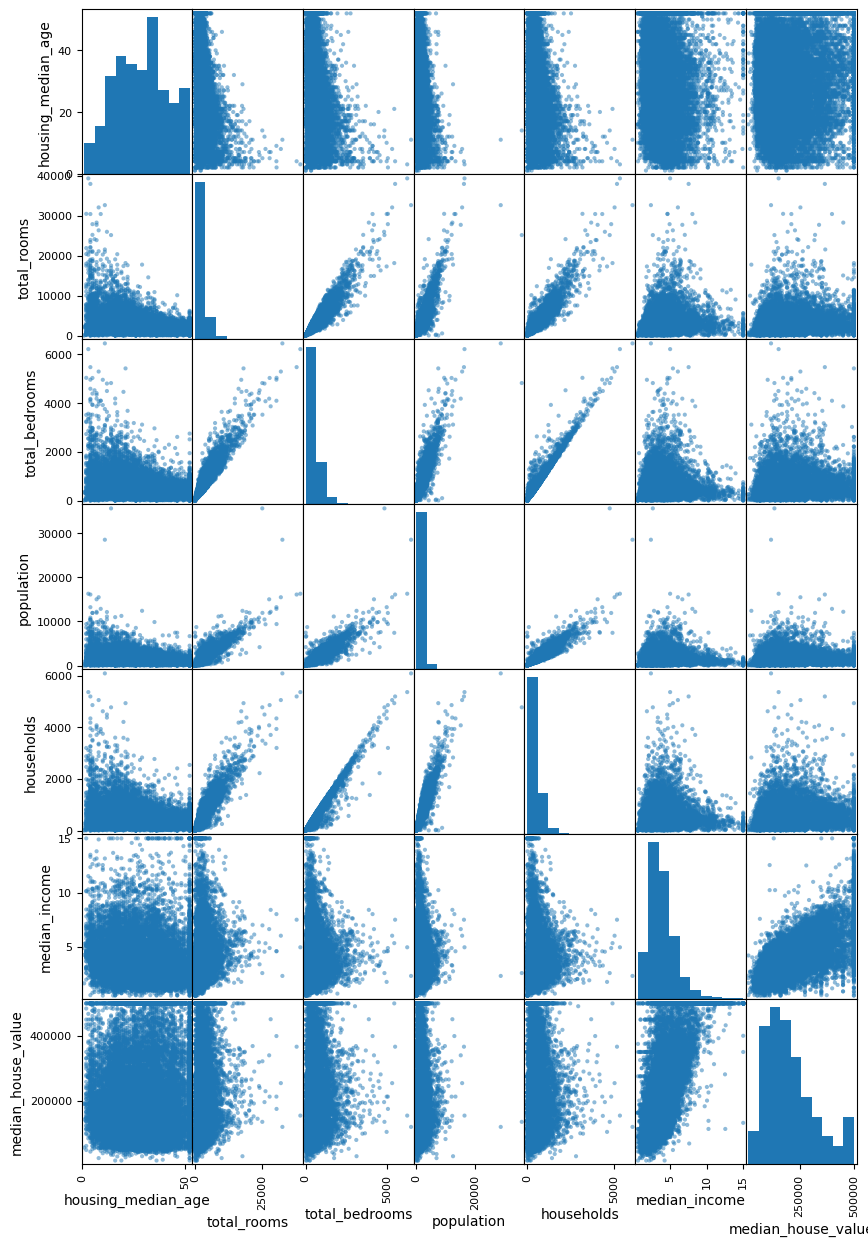

In [20]:
pd.plotting.scatter_matrix(dfHousing[attributes], figsize = (10, 15))
plt.show()

A nice way to view the correlation between attributes is to use Pandas’ `scatter_matrix`
function, which plots every numerical attribute against every other numerical attribute. 
Since there are 11 numerical attributes, we would get 11 x 11 = 121 plots; You may therefore select the attributes which are essential:

**Note!** The main diagonal (top left to bottom right) would be full of straight lines if Pandas
plotted each variable against itself, which is not be very useful. So instead Pandas
displays a histogram of each attribute.


The most promising attribute to predict the median house value is the median
income, so let’s zoom in on their correlation scatterplot

This plot reveals a few things. First, the correlation is indeed very strong; you can
clearly see the upward trend and the points are not too dispersed. Second, the price
cap that we noticed earlier is clearly visible as a horizontal line at 500,000 USD. 

But this plot reveals other less obvious straight lines: a horizontal line around USD 450,000,
another around 350,000 USD, perhaps one around USD 280,000, and a few more below that.
You may want to try removing the corresponding districts to prevent your algorithms
from learning to reproduce these data quirks.

Before applying Machine Learning algorithms, it can be useful to try out various attribute combinations. For example, the total number of rooms in a district is not very useful if you don’t know how many households there are. What you really want is the **number of rooms per household**. Similarly, the total number of **bedrooms** by itself is not very useful: you probably want to **compare it to the number of rooms**. And the **population per household** also seems like an interesting attribute combination to look at. Here we will create these: 

In [21]:
dfHousing['rooms_per_household'] = dfHousing['total_rooms'] / dfHousing['households']

Again you may want to make some plots for the new variables.

In [22]:
dfHousing.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,rooms_per_household
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY,6.984127
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY,6.238137
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY,8.288136
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY,5.817352
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY,6.281853


## 4 Basic Statistics

In [23]:
dfHousing.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,rooms_per_household
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909,5.429000
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874,2.474173
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000,0.846154
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000,4.440716
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000,5.229129
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000,6.052381
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000,141.909091


You should comment on the observations you make. Maybe you can confirm a hypothesis or you can observe some surprising and counterintuitive observations.

## 5 Prepare data


### Remove or replace missing values
In what follows we will remove all the rows where the variable has missing values. We remove the rows because we do not have a plausible value that we can insert. Furthermore, there are not many missing values so we are confident that this will not screw our analysis.  
However, be careful if we run regression without this variable, we would not need to remove this rows.

Let us first check where the NaN's are.

In [24]:
dfHousing[dfHousing['total_bedrooms'].isnull()]

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,rooms_per_household
290,-122.16,37.77,47.0,1256.0,NaN,570.0,218.0,4.3750,161900.0,NEAR BAY,5.761468
341,-122.17,37.75,38.0,992.0,NaN,732.0,259.0,1.6196,85100.0,NEAR BAY,3.830116
538,-122.28,37.78,29.0,5154.0,NaN,3741.0,1273.0,2.5762,173400.0,NEAR BAY,4.048704
563,-122.24,37.75,45.0,891.0,NaN,384.0,146.0,4.9489,247100.0,NEAR BAY,6.102740
696,-122.10,37.69,41.0,746.0,NaN,387.0,161.0,3.9063,178400.0,NEAR BAY,4.633540
...,...,...,...,...,...,...,...,...,...,...,...
20267,-119.19,34.20,18.0,3620.0,NaN,3171.0,779.0,3.3409,220500.0,NEAR OCEAN,4.646983
20268,-119.18,34.19,19.0,2393.0,NaN,1938.0,762.0,1.6953,167400.0,NEAR OCEAN,3.140420
20372,-118.88,34.17,15.0,4260.0,NaN,1701.0,669.0,5.1033,410700.0,<1H OCEAN,6.367713
20460,-118.75,34.29,17.0,5512.0,NaN,2734.0,814.0,6.6073,258100.0,<1H OCEAN,6.771499


In [25]:
# We will first test without inplace = True. The resulting number of rows appears belowq the table
dfHousing.dropna(axis = 0, inplace = True)

In [26]:
# Now we will indeed remove the index



# NOTE NOTE NOTE
# As can be seen from the table above the indexes still go to 20639, while there are 20433 rows
# This means some indexes have been removed. This can cause a problem later (for example in the
# stratified splitting, we will therefor reindex the the new dataframe
# This has cost me 1 hour to figure out :-(

dfHousing.reset_index(inplace = True)

### Handling Categorical Variables

As we see the variable 'ocean_proximity' has five different text values. We will replace this categorical variable with dummy variables.

In [27]:
dfHousing = pd.get_dummies(dfHousing, drop_first = True)

In [28]:
dfHousing.tail()

,index,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,rooms_per_household,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
20428,20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,5.045455,True,False,False,False
20429,20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,6.114035,True,False,False,False
20430,20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,5.205543,True,False,False,False
20431,20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,5.329513,True,False,False,False
20432,20639,-121.24,39.37,16.0,2785.0,616.0,1387.0,530.0,2.3886,89400.0,5.254717,True,False,False,False


### Splitting the Data into Training and Test Set

In the following, we will partition the whole set into a training and into a test set.<br>
Here we will apply **random sampling** since the dataset is pretty large (and for simplicity).

#### Random Sampling

#### Stratified Sampling
You may consider **stratisfied sampling** if you want to preserve the same percentage for each target class like in the complete set. We will here look how it works for our dataset, but we won't use it later.

In [29]:
dfHousing['house_value_cat'] =  pd.cut(dfHousing['median_house_value'],
                                  bins=[0.0, 100000, 200000, 300000, 400000, float('inf')],
                                  labels=[1, 2, 3, 4, 5])

<Axes: >

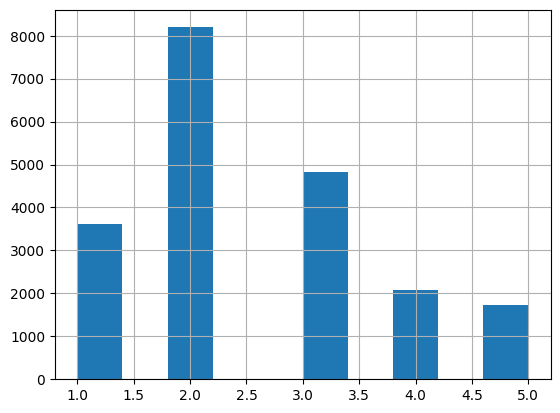

In [30]:
dfHousing['house_value_cat'].hist()

In [31]:
from sklearn.model_selection import StratifiedShuffleSplit
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
sss.get_n_splits(dfHousing, dfHousing['house_value_cat'])


1

In [32]:
# The following is just for seeing how it works

for train_index, test_index in sss.split(dfHousing, dfHousing['house_value_cat']):
    print(train_index)
    print(test_index)

# Note that there is only one iteration, since there is only one split (we could have split
# into several training and test sets)
 
print(len(train_index))
print(len(test_index))
    
    

[12958 11122  6296 ...  2632  9139  1025]
[15597 11493  7462 ...  4676   970  9024]
16346
4087


In [33]:
# Note that several splits would require a loop through the splits to create all the traing and test sets.
# See a separate file for this.

strat_train_set = dfHousing.loc[train_index]
strat_test_set = dfHousing.loc[test_index]


Let us now check how the income category is distributed in the test and training set.

In [34]:
strat_train_set['house_value_cat'].value_counts() / len(strat_train_set)

house_value_cat
2    0.401077
3    0.235960
1    0.176985
4    0.101493
5    0.084486
Name: count, dtype: float64

In [35]:
strat_test_set['house_value_cat'].value_counts() / len(strat_test_set)

house_value_cat
2    0.401272
3    0.235870
1    0.176902
4    0.101541
5    0.084414
Name: count, dtype: float64

We continue with the **random sampling**.

In [37]:
from sklearn.model_selection import train_test_split
train_set, test_set = train_test_split(dfHousing, test_size=0.2, random_state = 42)

In [38]:
train_set["house_value_cat"].value_counts() / len(train_set)

house_value_cat
2    0.401994
3    0.237795
1    0.176679
4    0.099413
5    0.084118
Name: count, dtype: float64

In [39]:
test_set["house_value_cat"].value_counts() / len(test_set)

house_value_cat
2    0.397602
3    0.228529
1    0.178126
4    0.109861
5    0.085882
Name: count, dtype: float64

### 6 Select and Train a Model

In what follows, we want to apply linear regression model.


Notice that his RMSE is not deterministic. It will most probably change when you rerun the code, becasue then another traing sample is generated.  
Anyway, this is clearly not a great score: most districts have a median_housing_values between USD 120,000 and USD 265,000, so a typical prediction error of around USD 65,000 is not very satisfying.

Hence, we would try to look for a better model. What can we do? There are several possibilities.
1. Add more variables
2. Reduce the number to the important variables
3. Try another model

Let us try another model, namely Decision Tree Regression (just for fun here, you will learn how this works later).


In [40]:
# Import the library


# Define the model


# Fit the model


# Predict with the model


# Calculate the MSE



No error at all?<br>
Can this model really be absolutely perfect?<br>
No. It is much more likely that the model has badly overfit the data. How can you be sure?
As we saw earlier, you don’t want to touch the test set until you are ready to launch a
model you are confident about, so you need to use part of the training set for training,
and part for model validation. One way to evaluate the Decision Tree model would be to use the train_test_split
function to split the training set into a smaller training set and a validation set, then train your models against the smaller training set and evaluate it against the validation set. 

## Forward Selection

**Step 0:** Let us look again at the correlations

You may actually run the whole script several times to see whether different models would be selected.

### Evaluate Your System on the Test Set